In [3]:
import pandas as pd


In [46]:
##LOAD DATASETS

listings=pd.read_csv("../data/raw/listings 2.csv")
calendar=pd.read_csv("../data/raw/calendar.csv.gz")
neighbourhoods=pd.read_csv("../data/raw/neighbourhoods.csv")
reviews=pd.read_csv("../data/raw/reviews.csv")


In [47]:
##Shape of the datasets(rows and columns)

listings.head()
listings.tail()
rows, columns=listings.shape
print("Rows:", rows)
print("Columns:", columns)
listings.columns.tolist()
listings.info()


Rows: 30259
Columns: 90
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30259 entries, 0 to 30258
Data columns (total 90 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            30259 non-null  int64  
 1   listing_url                                   30259 non-null  object 
 2   scrape_id                                     30259 non-null  int64  
 3   last_scraped                                  30259 non-null  object 
 4   source                                        30259 non-null  object 
 5   name                                          30258 non-null  object 
 6   description                                   29357 non-null  object 
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   30259 non-null  object 
 9   host_id                              

| Column | My Understanding |
|---------|------------------|
| id | Unique listing ID |
| host_id | Unique host ID |
| host_name | Name of host |
| price | Listing price |
| latitude | Latitude of property |
| longitude | Longitude of property |

In [52]:
## Check for missing values 
missing_report = pd.DataFrame({
    "Column Name": listings.columns,
    "Missing Values": listings.isnull().sum().values,
    "Missing Percentage":
        (
            listings.isnull().sum()/len(listings)
        ).values*100
})

missing_report = missing_report.sort_values(
    by="Missing Percentage",
    ascending=False
)

missing_report

,Column Name,Missing Values,Missing Percentage
33,neighbourhood,30259,100.0
84,instant_bookable,30259,100.0
27,host_neighbourhood,30259,100.0
25,host_thumbnail_url,30259,100.0
23,host_acceptance_rate,30259,100.0
...,...,...,...
59,maximum_nights_avg_ntm,0,0.0
62,availability_30,0,0.0
63,availability_60,0,0.0
64,availability_90,0,0.0


In [50]:
## Create a new report 

missing_report = pd.DataFrame({
    "Column Name": listings.columns,
    "Missing Values": listings.isnull().sum().values,
    "Missing Percentage": (listings.isnull().sum() / len(listings) * 100).values
})

missing_report = missing_report.sort_values(
    by="Missing Percentage",
    ascending=False
)

missing_report

,Column Name,Missing Values,Missing Percentage
33,neighbourhood,30259,100.0
84,instant_bookable,30259,100.0
27,host_neighbourhood,30259,100.0
25,host_thumbnail_url,30259,100.0
23,host_acceptance_rate,30259,100.0
...,...,...,...
59,maximum_nights_avg_ntm,0,0.0
62,availability_30,0,0.0
63,availability_60,0,0.0
64,availability_90,0,0.0


In [56]:
## Creating a csv file

missing_report.to_csv("../data/reports/missing_report.csv", index=False)

In [55]:
## Checking for duplicates

duplicate_rows=listings.duplicated().sum()

print(f"Duplicated Rows:{duplicate_rows}")

Duplicated Rows:0


In [65]:
listings.columns.tolist()

['id',
 'listing_url',
 'scrape_id',
 'last_scraped',
 'source',
 'name',
 'description',
 'neighborhood_overview',
 'picture_url',
 'host_id',
 'host_url',
 'host_profile_id',
 'host_profile_url',
 'host_name',
 'host_since',
 'hosts_time_as_user_years',
 'hosts_time_as_user_months',
 'hosts_time_as_host_years',
 'hosts_time_as_host_months',
 'host_location',
 'host_about',
 'host_response_time',
 'host_response_rate',
 'host_acceptance_rate',
 'host_is_superhost',
 'host_thumbnail_url',
 'host_picture_url',
 'host_neighbourhood',
 'host_listings_count',
 'host_total_listings_count',
 'host_verifications',
 'host_has_profile_pic',
 'host_identity_verified',
 'neighbourhood',
 'neighbourhood_cleansed',
 'neighbourhood_group_cleansed',
 'latitude',
 'longitude',
 'property_type',
 'room_type',
 'accommodates',
 'bathrooms',
 'bathrooms_text',
 'bedrooms',
 'beds',
 'amenities',
 'price',
 'price_quote_checkin_date',
 'price_quote_checkout_date',
 'price_quote_total_price',
 'price_quote

In [67]:
# Find all columns related to neighbourhood

for column in listings.columns:
    if "neighbourhood" in column.lower():
        print(column)

host_neighbourhood
neighbourhood
neighbourhood_cleansed
neighbourhood_group_cleansed


In [57]:
listings["room_type"].value_counts()

room_type
Entire home/apt    16808
Private room       12713
Hotel room           520
Shared room          218
Name: count, dtype: int64

-> Shows the different room types available across New York City

In [68]:
## Neighbourhood Analysis

listings["neighbourhood_cleansed"].value_counts()

neighbourhood_cleansed
Bedford-Stuyvesant            2089
Midtown                       1784
Williamsburg                  1516
Harlem                        1417
Hell's Kitchen                1365
                              ... 
Fort Wadsworth                   1
Oakwood                          1
Dongan Hills                     1
Bay Terrace, Staten Island       1
New Springville                  1
Name: count, Length: 223, dtype: int64

-> Shows us the top 10 Neighbourhoods preffered by the customers

In [33]:
## Price Distribution

listings["price"].describe()

count    21797.000000
mean       278.325962
std        528.538586
min          5.000000
25%         98.000000
50%        176.000000
75%        304.000000
max      30973.000000
Name: price, dtype: float64

The above output shows the price distribution, for example 50% of the room prices start at $176.

In [35]:
## Property availability

availability_category = pd.cut(
    listings["availability_365"],
    bins=[-1, 0, 90, 180, 365],
    labels=[
        "Not Available",
        "Low Availability",
        "Medium Availability",
        "High Availability"
    ]
)

availability_category.value_counts()

availability_365
High Availability      16258
Not Available           6801
Low Availability        3780
Medium Availability     3716
Name: count, dtype: int64

 1. Approximately 40% of listings are available for more than 180 days a year. This could indicate lower demand in certain neighborhoods or hosts intentionally keeping calendars open. Further analysis by neighborhood and room type may reveal opportunities to optimize pricing or marketing.

# Exploratory Data profiling

In [59]:
## Room type distribution

room_type_counts=listings["room_type"].value_counts()

room_type_counts

room_type
Entire home/apt    16808
Private room       12713
Hotel room           520
Shared room          218
Name: count, dtype: int64

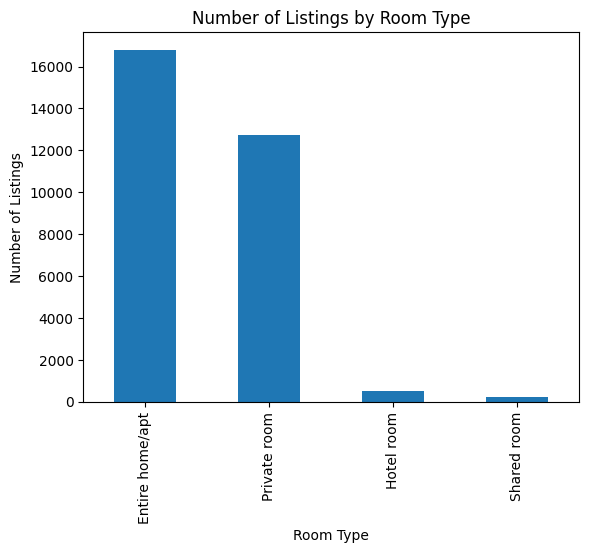

In [60]:
## Visualize the data

import matplotlib.pyplot as plt

room_type_counts.plot(kind="bar")

plt.title("Number of Listings by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Number of Listings")
plt.savefig("../visuals/room_type_distribution.png")
plt.show()

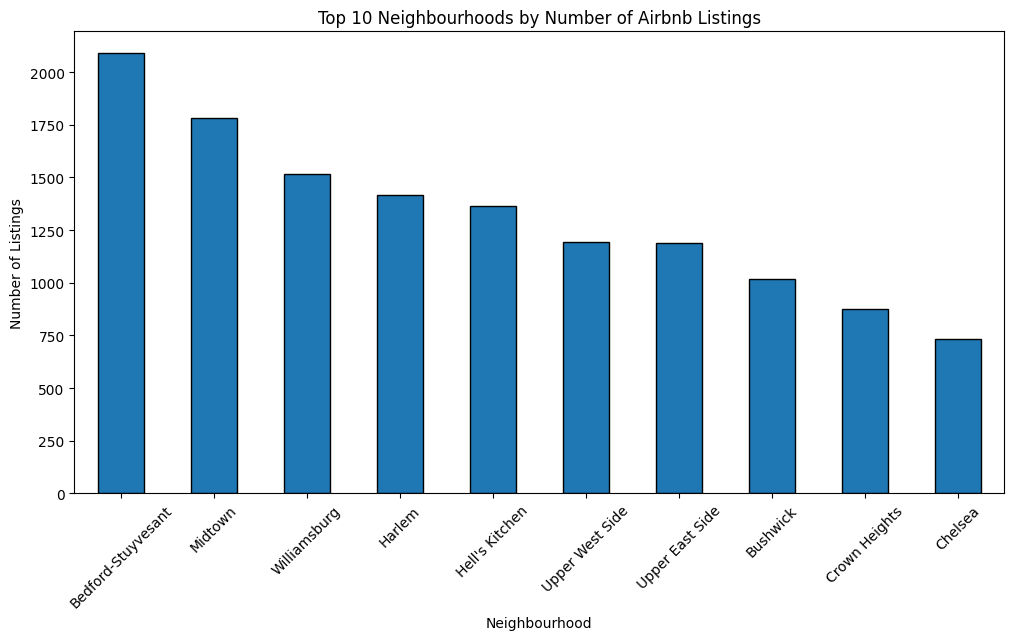

In [72]:
## Top 10 Neighbourhoods

top_neighbourhoods = (
    listings["neighbourhood_cleansed"]
    .value_counts()
    .head(10)
)

top_neighbourhoods

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

top_neighbourhoods.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Top 10 Neighbourhoods by Number of Airbnb Listings")
plt.xlabel("Neighbourhood")
plt.ylabel("Number of Listings")
plt.xticks(rotation=45)
plt.savefig("../visuals/top_10_neighbourhood.png")
plt.show()

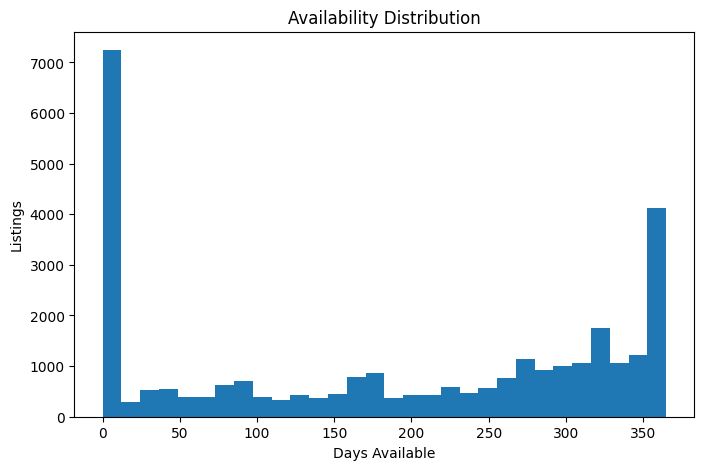

In [73]:
## Availability Duration

plt.figure(figsize=(8,5))

plt.hist(listings["availability_365"], bins=30)

plt.title("Availability Distribution")
plt.xlabel("Days Available")
plt.ylabel("Listings")
plt.savefig("../visuals/availability_distribution.png")
plt.show()

In [74]:
## Correlation

numeric_columns = listings.select_dtypes(include="number")

correlation = numeric_columns.corr()

correlation

,id,scrape_id,neighborhood_overview,host_id,host_profile_id,host_since,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
id,1.000000,NaN,NaN,0.069298,0.285579,NaN,-0.482468,-0.042308,-0.553324,-0.036260,...,-0.067174,-0.092791,-0.057758,-0.109641,NaN,0.123980,0.113061,0.030078,0.098302,0.171404
scrape_id,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighborhood_overview,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,0.069298,NaN,NaN,1.000000,0.357670,NaN,-0.084414,-0.057207,-0.068902,-0.063309,...,0.001644,0.005027,0.007763,0.006093,NaN,-0.012269,-0.010361,-0.008529,-0.001162,0.007314
host_profile_id,0.285579,NaN,NaN,0.357670,1.000000,NaN,-0.290376,-0.062129,-0.334144,-0.131909,...,-0.008418,-0.009038,-0.002512,-0.005894,NaN,-0.067755,-0.065779,-0.021072,0.000686,0.118480
host_since,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hosts_time_as_user_years,-0.482468,NaN,NaN,-0.084414,-0.290376,NaN,1.000000,-0.034497,0.778623,0.001807,...,0.102222,0.130243,0.098573,0.134479,NaN,-0.004256,0.018709,-0.068890,-0.059019,-0.211850
hosts_time_as_user_months,-0.042308,NaN,NaN,-0.057207,-0.062129,NaN,-0.034497,1.000000,0.029762,0.386812,...,0.000095,-0.008179,-0.032109,-0.013142,NaN,-0.012778,-0.059085,0.241623,0.018963,-0.007176
hosts_time_as_host_years,-0.553324,NaN,NaN,-0.068902,-0.334144,NaN,0.778623,0.029762,1.000000,-0.051982,...,0.047510,0.053975,0.052942,0.046367,NaN,0.097852,0.101596,0.017644,-0.061892,-0.206801
hosts_time_as_host_months,-0.036260,NaN,NaN,-0.063309,-0.131909,NaN,0.001807,0.386812,-0.051982,1.000000,...,0.001389,-0.000481,-0.024486,-0.001383,NaN,-0.022747,-0.046279,0.128741,0.041354,-0.007947


# Business Insights from Data Profiling

## Key Findings

- The dataset contains **30,555 Airbnb listings** with **90+ features** covering hosts, listings, pricing, reviews, and availability.
- The **license** column has the highest percentage of missing values and will require evaluation before analysis.
- Review-related columns (`last_review`, `reviews_per_month`) contain missing values, likely due to listings with no customer reviews.
- The dataset contains a mix of numerical, categorical, boolean, and date fields, making it suitable for comprehensive business analysis.
- Listing prices show a wide range of values, indicating potential outliers that require further investigation.
- The dataset includes rich host, property, review, and location information, enabling pricing, customer satisfaction, and host performance analysis.
